In [3]:

import os
import sys

import matplotlib.pyplot as plt
import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)

ATTRIBUTE_NAMES = ["ARC", "BC", "CM", "FM", "FOC", "IV", "LR", "OV", "POC", "SOB", "SV", "VC"]

abbr_to_full = {
    "ARC": "aspect-ratio change",
    "BC": "background clutter",
    "CM": "camera motion",
    "FM": "fast motion",
    "FOC": "full occlusion",
    "IV": "illumination variation",
    "LR": "low resolution",
    "OV": "out of view",
    "POC": "partial occlusion",
    "SOB": "similar object / di.actors",
    "SV": "scale variation",
    "VC": "viewpoint change",
}

# Clone PySOT repo
# !git clone https://github.com/STVIR/pysot.git
# !cd pysot
# !pip install -r requirements.txt
# !python setup.py install

# clone this first
# restart notebook and run again


sys.path.append("/home/moha/AIC-4/external/SiamABC")
sys.path.append("..")

In [4]:
UAV123_df = pd.read_csv("../data/UAV123.csv")
DTB70_df = pd.read_csv("../data/DTB70.csv")
UAVTrack_df = pd.read_csv("../data/UAVTrack112.csv")
UAV123_df


FileNotFoundError: [Errno 2] No such file or directory: '../data/UAV123.csv'

In [ ]:
# ----------------------------
# UAV123 + UAV20L split
# ----------------------------
from sklearn.model_selection import train_test_split

long_uav20l_sequences = UAV123_df[UAV123_df["uav20L_seq"] == 1]
long_uav20l_seq_paths = long_uav20l_sequences["seq_path"].unique()

uav123_train_paths, uav123_test_paths = train_test_split(
    long_uav20l_seq_paths, test_size=0.9, random_state=42
)

uav123_train_df = pd.concat([
    UAV123_df[UAV123_df["seq_path"].isin(uav123_train_paths)],
    UAV123_df[UAV123_df["uav20L_seq"] == 0]
])

uav123_test_df = UAV123_df[UAV123_df["seq_path"].isin(uav123_test_paths)]

n_uav20l_in_train = uav123_train_df["uav20L_seq"].sum()
n_non_uav20l_in_train = len(uav123_train_df) - n_uav20l_in_train

n_uav20l_in_test = uav123_test_df["uav20L_seq"].sum()
n_non_uav20l_in_test = len(uav123_test_df) - n_uav20l_in_test

print("----- UAV123 Dataset Split -----")
print(f"Train sequences: {len(uav123_train_df)}")
print(f"  UAV20L sequences in train: {n_uav20l_in_train}")
print(f"  Non-UAV20L sequences in train: {n_non_uav20l_in_train}\n")

print(f"Test sequences: {len(uav123_test_df)}")
print(f"  UAV20L sequences in test: {n_uav20l_in_test}")
print(f"  Non-UAV20L sequences in test: {n_non_uav20l_in_test}\n")

split_ratio = len(uav123_test_df) / (len(uav123_train_df) + len(uav123_test_df))
print(f"Test / Total sequences ratio: {split_ratio:.2f}\n")

# ----------------------------
# DTB70 split
# ----------------------------
train_DTB70, test_DTB70 = train_test_split(DTB70_df, test_size=0.2, random_state=42)
print("----- DTB70 Dataset Split -----")
print(f"Train sequences: {len(train_DTB70)}")
print(f"Test sequences: {len(test_DTB70)}")
print(f"Test / Total sequences ratio: {len(test_DTB70) / len(DTB70_df):.2f}\n")

# ----------------------------
# UAVTrack112 split based on length
# ----------------------------
length_threshold = 1300
test_UAVTrack = UAVTrack_df[UAVTrack_df["n_frames"] >= length_threshold]
train_UAVTrack = UAVTrack_df[UAVTrack_df["n_frames"] < length_threshold]
print("----- UAVTrack112 Dataset Split -----")
print(f"Train sequences: {len(train_UAVTrack)}")
print(f"Test sequences: {len(test_UAVTrack)}")
print(f"Test / Total sequences ratio: {len(test_UAVTrack) / len(UAVTrack_df):.2f}\n")

# ----------------------------
#  check leakage for UAV123
# ----------------------------
train_seqs = set(uav123_train_df["seq_path"].unique())
test_seqs = set(uav123_test_df["seq_path"].unique())
if train_seqs.isdisjoint(test_seqs):
    print("No leakage: UAV123 train and test sequences are disjoint ✅")
else:
    print("Leakage detected in UAV123 sequences! ❌")

----- UAV123 Dataset Split -----
Train sequences: 81
  UAV20L sequences in train: 7
  Non-UAV20L sequences in train: 74

Test sequences: 42
  UAV20L sequences in test: 42
  Non-UAV20L sequences in test: 0

Test / Total sequences ratio: 0.34

----- DTB70 Dataset Split -----
Train sequences: 56
Test sequences: 14
Test / Total sequences ratio: 0.20

----- UAVTrack112 Dataset Split -----
Train sequences: 81
Test sequences: 31
Test / Total sequences ratio: 0.28

No leakage: UAV123 train and test sequences are disjoint ✅


In [ ]:
# ----------------------------
# Concatenate all training DataFrames
# ----------------------------
train_df = pd.concat([
    uav123_train_df,
    train_DTB70,
    train_UAVTrack
], ignore_index=True)

# ----------------------------
# Concatenate all testing DataFrames
# ----------------------------
test_df = pd.concat([
    uav123_test_df,
    test_DTB70,
    test_UAVTrack
], ignore_index=True)


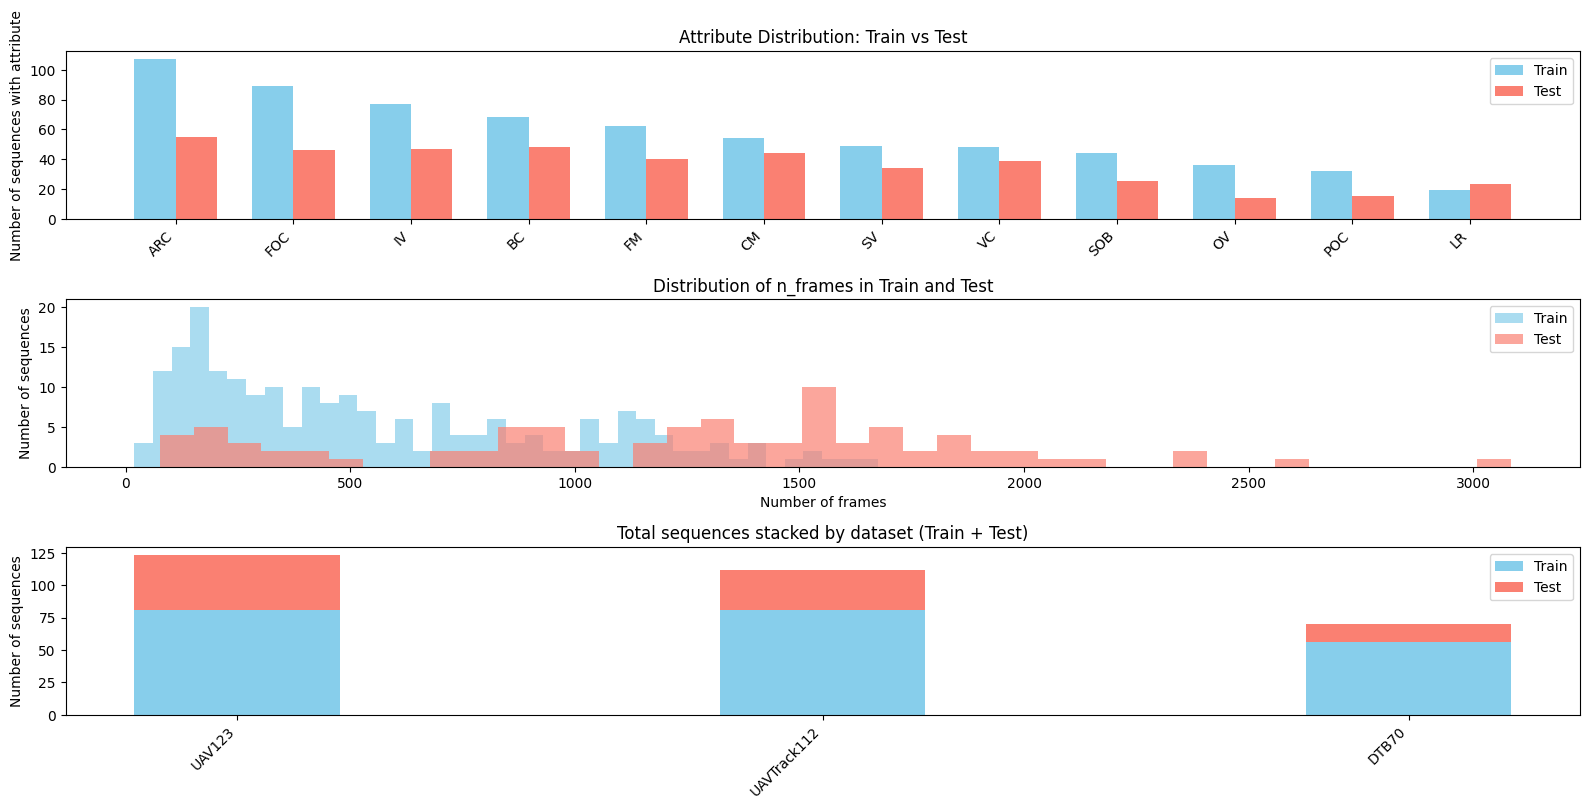

In [ ]:


train_attr_counts = train_df[ATTRIBUTE_NAMES].sum(axis=0)
test_attr_counts = test_df[ATTRIBUTE_NAMES].sum(axis=0)

attr_counts = pd.DataFrame({
    "Train": train_attr_counts,
    "Test": test_attr_counts
}).sort_values(by="Train", ascending=False)

x_attr = np.arange(len(attr_counts))
width = 0.35

dataset_counts_train = train_df["dataset"].value_counts()
dataset_counts_test = test_df["dataset"].value_counts()

datasets = list(set(dataset_counts_train.index) | set(dataset_counts_test.index))
dataset_counts_train = dataset_counts_train.reindex(datasets, fill_value=0)
dataset_counts_test = dataset_counts_test.reindex(datasets, fill_value=0)
x_dataset = np.arange(len(datasets))

fig, axes = plt.subplots(3, 1, figsize=(16, 8))

axes[0].bar(x_attr - width / 2, attr_counts["Train"], width, label="Train", color="skyblue")
axes[0].bar(x_attr + width / 2, attr_counts["Test"], width, label="Test", color="salmon")
axes[0].set_xticks(x_attr)
axes[0].set_xticklabels(attr_counts.index, rotation=45, ha="right")
axes[0].set_ylabel("Number of sequences with attribute")
axes[0].set_title("Attribute Distribution: Train vs Test")
axes[0].legend()

bins = 40
axes[1].hist(train_df["n_frames"], bins=bins, alpha=0.7, label="Train", color="skyblue")
axes[1].hist(test_df["n_frames"], bins=bins, alpha=0.7, label="Test", color="salmon")
axes[1].set_title("Distribution of n_frames in Train and Test")
axes[1].set_xlabel("Number of frames")
axes[1].set_ylabel("Number of sequences")
axes[1].legend()

axes[2].bar(x_dataset, dataset_counts_train.values, width, label="Train", color="skyblue")
axes[2].bar(x_dataset, dataset_counts_test.values, width, bottom=dataset_counts_train.values,
            label="Test", color="salmon")
axes[2].set_xticks(x_dataset)
axes[2].set_xticklabels(datasets, rotation=45, ha="right")
axes[2].set_ylabel("Number of sequences")
axes[2].set_title("Total sequences stacked by dataset (Train + Test)")
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import torch
from hydra.utils import instantiate

/home/moha/miniconda3/envs/SiamABC/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import sys

print(sys.executable)

/home/moha/miniconda3/envs/SiamABC/bin/python


In [ ]:
# !cd ~/AIC-4/SiamABC
# !pip install \
#   albumentations==1.0.0 \
#   albumentations-experimental==0.0.1 \
#   coloredlogs==15.0.1 \
#   Cython==0.29.14 \
#   fire==0.3.1 \
#   hydra-core==1.1.0 \
#   omegaconf==2.1.2 \
#   opencv-contrib-python-headless \
#   pandas==1.1.3 \
#   pytorch-toolbelt==0.4.3 \
#   pytorchcv==0.0.65 \
#   tensorboard==2.4.1 \
#   torchmetrics==0.3.2 \
#   thop==0.0.31-2005241907 \
#   imageio==2.20.0 \
#   imageio-ffmpeg==0.4.7 \
#   "protobuf<4.21.0" \
#   numpy==1.17.3

# # Install the git-based dependencies
# !pip install spikingjelly
# !pip install -e git+https://github.com/facebookresearch/mobile-vision.git@51804a6873ae1029257cf652179c960cceeecc75#egg=mobile_cv
# !pip install git+https://github.com/KupynOrest/toolkit.git
# !pip install -e src/mobile-cv/

In [ ]:
data = pd.read_csv("/home/moha/AIC-4/train_dataframe.csv")
data

,video_path,annotation_path,start_idx,end_idx,n_frames,native_fps,class,seq_name,dataset,split,seq_key
0,dataset1/Car_video_2/Car_video_2.mp4,dataset1/Car_video_2/annotation.txt,1,678,678,60.0,Car_video,Car_video_2,dataset1,train,dataset1/Car_video_2
1,dataset1/Car_video_3/Car_video_3.mp4,dataset1/Car_video_3/annotation.txt,1,223,223,24.0,Car_video,Car_video_3,dataset1,train,dataset1/Car_video_3
2,dataset1/horse_4/horse_4.mp4,dataset1/horse_4/annotation.txt,1,235,235,25.0,horse,horse_4,dataset1,train,dataset1/horse_4
3,dataset1/horse_6/horse_6.mp4,dataset1/horse_6/annotation.txt,1,448,448,30.0,horse,horse_6,dataset1,train,dataset1/horse_6
4,dataset1/motorcycle/motorcycle.mp4,dataset1/motorcycle/annotation.txt,1,801,801,30.0,motorcycle,motorcycle,dataset1,train,dataset1/motorcycle
...,...,...,...,...,...,...,...,...,...,...,...
250,dataset5/wakeboard3/wakeboard3_96.mp4,dataset5/wakeboard3/annotation.txt,1,823,823,96.0,wakeboard,wakeboard3,dataset5,train,dataset5/wakeboard3
251,dataset5/wakeboard4/wakeboard4_96.mp4,dataset5/wakeboard4/annotation.txt,1,697,697,96.0,wakeboard,wakeboard4,dataset5,train,dataset5/wakeboard4
252,dataset5/wakeboard5/wakeboard5_96.mp4,dataset5/wakeboard5/annotation.txt,1,1675,1675,96.0,wakeboard,wakeboard5,dataset5,train,dataset5/wakeboard5
253,dataset5/wakeboard8/wakeboard8_96.mp4,dataset5/wakeboard8/annotation.txt,1,1543,1543,96.0,wakeboard,wakeboard8,dataset5,train,dataset5/wakeboard8


In [ ]:
train_dataset_full = pd.concat([
    train_df, test_df
]).reset_index()

train_dataset_full

,index,seq_path,annot_path,ARC,BC,CM,FM,FOC,IV,LR,...,is_shared_annot,H,W,uav20L_seq,class,start_idx,end_idx,n_frames,dataset,at_night
0,0,/home/moha/AIC-4/data/UAV123/data_seq/UAV123/g...,/home/moha/AIC-4/data/UAV123/anno/UAV123/group...,1.0,1.0,1.0,0.0,0.0,1.0,0.0,...,1.0,720,1280,1.0,group,1,1567,1566,UAV123,NaN
1,1,/home/moha/AIC-4/data/UAV123/data_seq/UAV123/g...,/home/moha/AIC-4/data/UAV123/anno/UAV123/group...,1.0,1.0,1.0,0.0,1.0,1.0,0.0,...,1.0,720,1280,1.0,group,4369,5527,1158,UAV123,NaN
2,2,/home/moha/AIC-4/data/UAV123/data_seq/UAV123/g...,/home/moha/AIC-4/data/UAV123/anno/UAV123/group...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,720,1280,1.0,group,2827,4369,1542,UAV123,NaN
3,3,/home/moha/AIC-4/data/UAV123/data_seq/UAV123/p...,/home/moha/AIC-4/data/UAV123/anno/UAV123/perso...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,720,1280,1.0,person,847,1813,966,UAV123,NaN
4,4,/home/moha/AIC-4/data/UAV123/data_seq/UAV123/g...,/home/moha/AIC-4/data/UAV123/anno/UAV123/group...,1.0,1.0,1.0,0.0,1.0,1.0,0.0,...,1.0,720,1280,1.0,group,1567,2827,1260,UAV123,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300,82,/home/moha/AIC-4/data/UAVTrack112/V4RFlight112...,/home/moha/AIC-4/data/UAVTrack112/V4RFlight112...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,NaN,720,1280,NaN,air conditioning box,1,1847,1847,UAVTrack112,False
301,83,/home/moha/AIC-4/data/UAVTrack112/V4RFlight112...,/home/moha/AIC-4/data/UAVTrack112/V4RFlight112...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,NaN,720,1280,NaN,uav,1,1520,1520,UAVTrack112,False
302,84,/home/moha/AIC-4/data/UAVTrack112/V4RFlight112...,/home/moha/AIC-4/data/UAVTrack112/V4RFlight112...,0.0,0.0,1.0,1.0,1.0,1.0,0.0,...,NaN,720,1280,NaN,human,1,1605,1605,UAVTrack112,False
303,85,/home/moha/AIC-4/data/UAVTrack112/V4RFlight112...,/home/moha/AIC-4/data/UAVTrack112/V4RFlight112...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,...,NaN,720,1280,NaN,basketball player,1,1567,1567,UAVTrack112,True


In [ ]:
from torch.utils.data import DataLoader

from utils.dataset import UAV123TrackingDataset

tracking_config = {
    "template_size": 128,
    "instance_size": 256,
    "score_size": 16,
    "search_context": 2,
    "max_frame_gap": 200,
    "total_stride": 16,
    "template_bbox_offset": 0.2,
    "search_image_shift": 1,
    "search_image_scale": 0.3,
    "template_image_shift": 0.01,
    "template_image_scale": 0.01,

}

train_dataset = UAV123TrackingDataset(
    dataframe=train_dataset_full,
    tracking_config=tracking_config,
    num_samples=5000,
    neg_ratio=1,
    seed=42,
    # distractor_db_path = "/home/moha/AIC-4/data/distractor_db.pkl"
)

test_dataset = UAV123TrackingDataset(
    dataframe=test_df,
    tracking_config=tracking_config,
    num_samples=2,
    neg_ratio=-0.001,
    seed=42,
    # data_root       = "../data_competition",
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          num_workers=0)
val_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,
                        num_workers=0)

[Dataset] 305 sequences | sources={'UAV123': 123, 'UAVTrack112': 112, 'DTB70': 70} | num_samples=5000 | neg_ratio=100% | template_size=128 | instance_size=256 | score_size=16
[Dataset] 87 sequences | sources={'UAV123': 42, 'UAVTrack112': 31, 'DTB70': 14} | num_samples=2 | neg_ratio=-0% | template_size=128 | instance_size=256 | score_size=16


In [ ]:
from utils.hydra import load_hydra_config_from_path
from models.SiamABC.tracker.tracker_setup import load_model

config_path = "../external/SiamABC/core/config"
config_name = "SiamABC_tracker"
weights_path = "/home/moha/AIC-4/checkpoints/bbox_head/all_datasets_finetuning/part_2/head_epoch_001.pth"
config = load_hydra_config_from_path(config_path=config_path, config_name=config_name)

config["model"]["model_size"] = "M"

config["model"]["build_simsiam_heads"] = False
config["tracker"]["dynamic_update"] = True
config["tracker"]["window_influence"] = 0.05
config["tracker"]["N"] = 50

model = instantiate(config["model"])
model = load_model(model, weights_path, strict=False).cuda().eval()
model

SiamABCNet(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(6

(torch.Size([3, 128, 128]),
 torch.Size([3, 128, 128]),
 torch.Size([3, 256, 256]),
 torch.Size([3, 256, 256]),
 torch.Size([1, 16, 16]),
 torch.Size([4, 16, 16]),
 torch.Size([16, 16]))

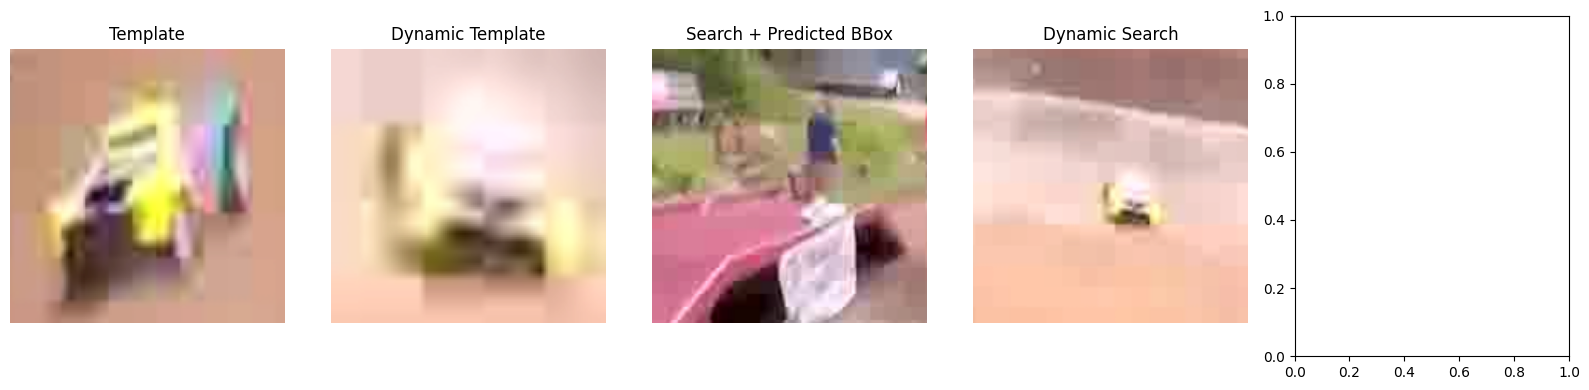

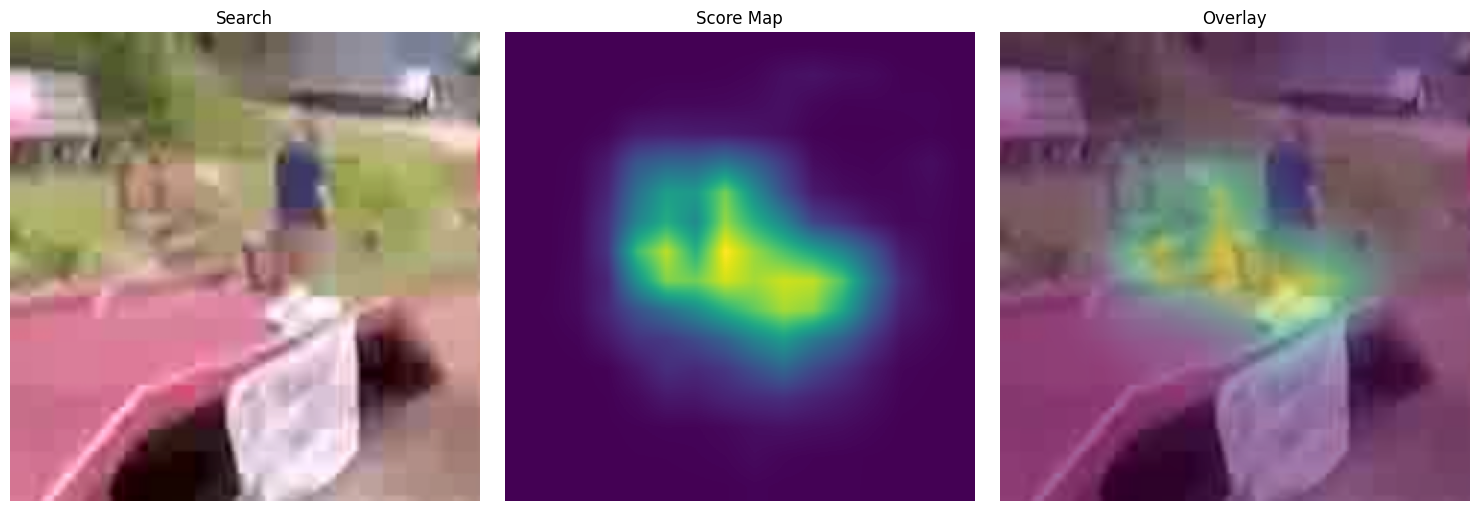

is_positive: False


In [ ]:

import traceback

import matplotlib.pyplot as plt
from matplotlib import patches

try:
    sample = train_dataset[0]
except Exception:
    traceback.print_exc()

import torch.nn.functional as F

from utils.box_coder import SiamABCBoxCoder

box_coder = SiamABCBoxCoder(config["tracker"])

template = sample['template']
dynamic_template = sample['dynamic_template']
search = sample['search']
dynamic_search = sample['dynamic_search']
cls_label = sample['cls_label']
bbox_label = sample['bbox_label']
reg_weight = sample['reg_weight']
is_positive = sample['is_positive']

decoded = box_coder.decode(
    bbox_label.unsqueeze(0),  # Add batch dimension

    cls_label.unsqueeze(0)
)

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]


def unnormalize(tensor, mean, std):
    mean = torch.tensor(mean, device=tensor.device).view(-1, 1, 1)
    std = torch.tensor(std, device=tensor.device).view(-1, 1, 1)
    return (tensor * std + mean) * 255


template_plot = unnormalize(template, mean, std)
dynamic_template_plot = unnormalize(dynamic_template, mean, std)
search_plot = unnormalize(search, mean, std)
dynamic_search_plot = unnormalize(dynamic_search, mean, std)

template_plot = torch.clamp(template_plot, 0, 255)
dynamic_template_plot = torch.clamp(dynamic_template_plot, 0, 255)
search_plot = torch.clamp(search_plot, 0, 255)
dynamic_search_plot = torch.clamp(dynamic_search_plot, 0, 255)


def to_numpy(img):
    return img.permute(1, 2, 0).numpy().astype(np.uint8)


# Plot
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

axes[0].imshow(to_numpy(template_plot))
axes[0].set_title("Template")
axes[0].axis("off")

axes[1].imshow(to_numpy(dynamic_template_plot))
axes[1].set_title("Dynamic Template")
axes[1].axis("off")

axes[2].imshow(to_numpy(search_plot))
axes[2].set_title("Search")
axes[2].axis("off")

rect = patches.Rectangle(
    (decoded.bbox[0][0].item(), decoded.bbox[0][1].item()), decoded.bbox[0][2].item(), decoded.bbox[0][3].item(),
    linewidth=2, edgecolor='r', facecolor='none'
)
axes[2].add_patch(rect)
axes[2].set_title("Search + Predicted BBox")
axes[2].axis("off")

axes[3].imshow(to_numpy(dynamic_search_plot))
axes[3].set_title("Dynamic Search")
axes[3].axis("off")

# axes[4].imshow(
#     Image.open(sample["path"]), cmap="viridis")
# axes[4].set_title("Original Frame")
# axes[4].axis("off")

plt.tight_layout()
plt.show()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with torch.no_grad():
    model_outs = model(
        (
            template.unsqueeze(0).to(device),
            dynamic_template.unsqueeze(0).to(device),
            search.unsqueeze(0).to(device),
            dynamic_search.unsqueeze(0).to(device)
        )
    )
scores = torch.sigmoid(model_outs["TARGET_CLASSIFICATION_KEY"][0])

score_map = F.interpolate(
    scores.unsqueeze(0),
    size=(256, 256),
    mode='bilinear',
    align_corners=False
)[0, 0].cpu().numpy()

score_map = (score_map - score_map.min()) / (score_map.max() - score_map.min() + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(to_numpy(search_plot))
axes[0].set_title("Search")
axes[0].axis("off")

axes[1].imshow(score_map, cmap="viridis")
axes[1].set_title("Score Map")
axes[1].axis("off")

axes[2].imshow(to_numpy(search_plot))
axes[2].imshow(score_map, cmap="viridis", alpha=0.5)
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()
print("is_positive:", is_positive.item())

In [ ]:
from models.SiamABC.tracker.tracker_setup import load_model
from utils.hydra import load_hydra_config_from_path

config_path = "../external/SiamABC/core/config"
config_name = "SiamABC_tracker"
weights_path = "/home/moha/AIC-4/checkpoints/bbox_head/all_datasets_finetuning/part_new /head_epoch_001.pth"
config = load_hydra_config_from_path(config_path=config_path, config_name=config_name)

config["model"]["model_size"] = "M"

config["model"]["build_simsiam_heads"] = False
config["tracker"]["dynamic_update"] = True
config["tracker"]["window_influence"] = 0.05
config["tracker"]["N"] = 50

model = instantiate(config["model"])
model = load_model(model, weights_path, strict=False).cuda().eval()
model

SiamABCNet(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(6

In [ ]:
# from utils.dataset_v import UAV123TrackingDataset
from torch.utils.data import DataLoader

tracking_config = {
    "template_size": 128,
    "instance_size": 256,
    "score_size": 16,
    "search_context": 2,
    "max_frame_gap": 130,
    "total_stride": 16,
    "template_bbox_offset": 0.2,
    "search_image_shift": 0.6,
    "search_image_scale": 0.3,
    "template_image_shift": 0.01,
    "template_image_scale": 0.01,

}

train_dataset = UAV123TrackingDataset(
    dataframe=train_dataset_full,
    tracking_config=tracking_config,
    num_samples=5000,
    neg_ratio=0.5,
    seed=42,
)

test_dataset = UAV123TrackingDataset(
    dataframe=test_df,
    tracking_config=tracking_config,
    num_samples=2,
    neg_ratio=-0.001,
    seed=42,
    # data_root       = "../data_competition",
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=0)
val_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,
                        num_workers=0)

[Dataset] 305 sequences | sources={'UAV123': 123, 'UAVTrack112': 112, 'DTB70': 70} | num_samples=5000 | neg_ratio=50% | template_size=128 | instance_size=256 | score_size=16
[Dataset] 87 sequences | sources={'UAV123': 42, 'UAVTrack112': 31, 'DTB70': 14} | num_samples=2 | neg_ratio=-0% | template_size=128 | instance_size=256 | score_size=16


In [ ]:
############ DAH YASTA ########### ########### ########### ########### ###########
############ DAH YASTA ########### ########### ########### ########### ###########
############ DAH YASTA ########### ########### ########### ########### ###########
############ DAH YASTA ########### ########### ########### ########### ###########

import torch
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

from utils.losses import TrackingHeadLoss
from utils.training import _train_one_epoch, freeze_backbone_only

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
# freeze_for_reg_only(model)
freeze_backbone_only(
    model
)
NUM_EPOCHS = 30
cls_params = [p for p in model.parameters() if p.requires_grad]

backbone_params = [p for p in model.encoder.parameters() if p.requires_grad]
head_params = [p for p in model.connect_model.parameters() if p.requires_grad]

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": 1e-5},
    {"params": head_params, "lr": 2e-4},
], weight_decay=1e-4)

warmup = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=3)
cosine = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - 3, eta_min=1e-6)
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[3])

criterion = TrackingHeadLoss(cls_weight=3, bbox_weight=0,
                             focal_alpha=0.25, focal_gamma=1.5).to(device)

save_dir = "../checkpoints/finetuned/"
os.makedirs(save_dir, exist_ok=True)
best_val = float("inf")
START_EPOCH = 2
for epoch in range(START_EPOCH, NUM_EPOCHS + 1):
    print(f"\n── Epoch {epoch}/{NUM_EPOCHS} ──")
    train_losses = _train_one_epoch(model, train_loader, optimizer, criterion, device, epoch, log_every=1)
    # val_losses   = _validate_one_epoch(model, train_loader, criterion, device)
    scheduler.step()

    print(
        f"  train loss={train_losses['total']:.4f}  "
        f"cls loss={train_losses['cls_loss']:.4f}  bbox loss={train_losses['bbox_loss']:.4f}\n"
        # f"  val   loss={val_losses['total']:.4f}  "
        # f"cls={val_losses['cls_loss']:.4f}  bbox={val_losses['bbox_loss']:.4f}\n"
        # f"  lr={scheduler.get_last_lr()[0]:.2e}"
    )

    state = {"module." + k: v for k, v in model.state_dict().items()}
    torch.save(state, f"{save_dir}/head_epoch_{epoch:03d}.pth")

    # if val_losses["total"] < best_val:
    #     best_val = val_losses["total"]
    #     torch.save(state, f"{save_dir}/head_best.pth")
    #     print(f"  ★ new best: {best_val:.4f}")


Frozen    : 8,543,296  (81.7%)
Trainable : 1,914,381  (18.3%)
Total     : 10,457,677

Trainable modules:
  BoxTower                                  1,124,364 params

── Epoch 2/30 ──
  step    1/157 | loss=0.0165  cls=0.0055  bbox=0.1634  pos=16/32  (2s)
  step    2/157 | loss=0.0149  cls=0.0050  bbox=0.1482  pos=14/32  (4s)
  step    3/157 | loss=0.0149  cls=0.0050  bbox=0.1378  pos=14/32  (7s)
  step    4/157 | loss=0.0155  cls=0.0052  bbox=0.1436  pos=17/32  (9s)
  step    5/157 | loss=0.0157  cls=0.0052  bbox=0.1453  pos=11/32  (11s)
  step    6/157 | loss=0.0152  cls=0.0051  bbox=0.1420  pos=12/32  (13s)
  step    7/157 | loss=0.0152  cls=0.0051  bbox=0.1450  pos=14/32  (15s)
  step    8/157 | loss=0.0143  cls=0.0048  bbox=0.1445  pos=18/32  (17s)
  step    9/157 | loss=0.0153  cls=0.0051  bbox=0.1466  pos=12/32  (19s)
  step   10/157 | loss=0.0152  cls=0.0051  bbox=0.1446  pos=16/32  (21s)
  step   11/157 | loss=0.0149  cls=0.0050  bbox=0.1441  pos=18/32  (23s)
  step   12/157 |

/home/moha/miniconda3/envs/SiamABC/lib/python3.7/site-packages/torch/optim/lr_scheduler.py:154: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


  step    1/157 | loss=0.0106  cls=0.0035  bbox=0.1123  pos=16/32  (2s)
  step    2/157 | loss=0.0226  cls=0.0075  bbox=0.1685  pos=11/32  (4s)
  step    3/157 | loss=0.0191  cls=0.0064  bbox=0.1622  pos=17/32  (6s)
  step    4/157 | loss=0.0180  cls=0.0060  bbox=0.1551  pos=15/32  (8s)
  step    5/157 | loss=0.0182  cls=0.0061  bbox=0.1584  pos=19/32  (11s)
  step    6/157 | loss=0.0170  cls=0.0057  bbox=0.1510  pos=15/32  (13s)
  step    7/157 | loss=0.0164  cls=0.0055  bbox=0.1524  pos=20/32  (15s)
  step    8/157 | loss=0.0186  cls=0.0062  bbox=0.1555  pos=13/32  (17s)
  step    9/157 | loss=0.0182  cls=0.0061  bbox=0.1537  pos=15/32  (19s)
  step   10/157 | loss=0.0182  cls=0.0061  bbox=0.1555  pos=15/32  (21s)
  step   11/157 | loss=0.0184  cls=0.0061  bbox=0.1589  pos=17/32  (23s)
  step   12/157 | loss=0.0181  cls=0.0060  bbox=0.1592  pos=19/32  (25s)
  step   13/157 | loss=0.0172  cls=0.0057  bbox=0.1561  pos=17/32  (27s)
  step   14/157 | loss=0.0168  cls=0.0056  bbox=0.1537 

KeyboardInterrupt: 